In [1]:
import torch
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path
import json
from itertools import combinations, permutations
import warnings
warnings.filterwarnings('ignore')

results_path = Path("../data/analysis/cls_emotion_vectors/emotion_pair_stats.pt")
metadata_path = Path("../data/analysis/cls_emotion_vectors/metadata.json")

print(f"Results path: {results_path}")
print(f"Results path exists: {results_path.exists()}")


Results path: ../data/analysis/cls_emotion_vectors/emotion_pair_stats.pt
Results path exists: True


In [2]:
results = torch.load(results_path)

stats = results['stats']
emotion_map = results['emotion_map']
start_layer = results['start_layer']
last_layer = results['last_layer']
normalize = results['normalize']

print("=" * 60)
print("DATASET METADATA")
print("=" * 60)
print(f"Model: google/vit-base-patch16-224-in21k")
print(f"Layer range: {start_layer} to {last_layer}")
print(f"Total layers analyzed: {last_layer - start_layer + 1}")
print(f"Vector normalization: {normalize}")
print(f"\nEmotion mapping: {emotion_map}")
print(f"Number of emotions: {len(emotion_map)}")
print(f"\nTotal emotion pairs analyzed: {len(stats)}")


DATASET METADATA
Model: google/vit-base-patch16-224-in21k
Layer range: 0 to 11
Total layers analyzed: 12
Vector normalization: True

Emotion mapping: {'neutrality': 0, 'happiness': 1, 'sadness': 2, 'anger': 3, 'disgust': 4, 'fear': 5}
Number of emotions: 6

Total emotion pairs analyzed: 12


In [4]:
stats.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])

In [11]:
EMOTION_TO_IDX = {
    "neutrality": 0,
    "happiness": 1,
    "sadness": 2,
    "anger": 3,
    "disgust": 4,
    "fear": 5,
}

IDX_TO_EMOTION = {v: k for k, v in EMOTION_TO_IDX.items()}

In [12]:
sample_layer = int(list(stats.keys())[1])
print(f"\nSample from layer {sample_layer}:")
sample_pairs = list(stats[sample_layer].keys())[:3]
for pair in sample_pairs:
    print(f"pair: {pair}")
    pair_data = stats[sample_layer][pair]
    print(f"\n  Pair: {IDX_TO_EMOTION[pair[0]]} → {IDX_TO_EMOTION[pair[1]]}")
    print(f"    Mean shape: {np.array(pair_data['mean']).shape}")
    print(f"    Std shape: {np.array(pair_data['std']).shape}")
    print(f"    Num identities: {pair_data['num_identities']}")
    print(f"    Mean magnitude: {np.linalg.norm(np.array(pair_data['mean'])):.4f}")
    print(f"    Std magnitude: {np.linalg.norm(np.array(pair_data['std'])):.4f}")



Sample from layer 1:
pair: (0, 1)

  Pair: neutrality → happiness
    Mean shape: (768,)
    Std shape: (768,)
    Num identities: 119
    Mean magnitude: 1.0000
    Std magnitude: 0.3339
pair: (0, 2)

  Pair: neutrality → sadness
    Mean shape: (768,)
    Std shape: (768,)
    Num identities: 119
    Mean magnitude: 1.0000
    Std magnitude: 0.3321
pair: (0, 3)

  Pair: neutrality → anger
    Mean shape: (768,)
    Std shape: (768,)
    Num identities: 119
    Mean magnitude: 1.0000
    Std magnitude: 0.3437


In [14]:
def compute_magnitude(vector):
    """Compute L2 norm of vector"""
    return np.linalg.norm(np.array(vector))

def compute_cosine_similarity(v1, v2):
    """Compute cosine similarity between two vectors"""
    v1 = np.array(v1)
    v2 = np.array(v2)
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-6)

data_list = []
for layer in stats:
    for (e1, e2), pair_data in stats[layer].items():
        mean_vec = np.array(pair_data['mean'])
        std_vec = np.array(pair_data['std'])
        
        data_list.append({
            'layer': int(layer),
            'emotion_from': IDX_TO_EMOTION[e1],
            'emotion_to': IDX_TO_EMOTION[e2],
            'emotion_pair': f"{IDX_TO_EMOTION[e1]} → {IDX_TO_EMOTION[e2]}",
            'mean_magnitude': compute_magnitude(mean_vec),
            'std_magnitude': compute_magnitude(std_vec),
            'mean_vector': mean_vec,
            'std_vector': std_vec,
            'num_identities': pair_data['num_identities']
        })

df = pd.DataFrame(data_list)
print(f"Created DataFrame with {len(df)} rows")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df[['layer', 'emotion_pair', 'mean_magnitude', 'std_magnitude', 'num_identities']].head(10))


Created DataFrame with 360 rows

DataFrame shape: (360, 9)

Columns: ['layer', 'emotion_from', 'emotion_to', 'emotion_pair', 'mean_magnitude', 'std_magnitude', 'mean_vector', 'std_vector', 'num_identities']

First few rows:
   layer            emotion_pair  mean_magnitude  std_magnitude  \
0      0  neutrality → happiness             0.0            0.0   
1      0    neutrality → sadness             0.0            0.0   
2      0      neutrality → anger             0.0            0.0   
3      0    neutrality → disgust             0.0            0.0   
4      0       neutrality → fear             0.0            0.0   
5      0  happiness → neutrality             0.0            0.0   
6      0     happiness → sadness             0.0            0.0   
7      0       happiness → anger             0.0            0.0   
8      0     happiness → disgust             0.0            0.0   
9      0        happiness → fear             0.0            0.0   

   num_identities  
0             119 

In [18]:
SELECT_EMOTION_FROM = "anger"
SELECT_EMOTION_TO = "disgust"


In [19]:
df_plot = df.copy()

if SELECT_EMOTION_FROM is not None:
    df_plot = df_plot[df_plot["emotion_from"] == SELECT_EMOTION_FROM]

if SELECT_EMOTION_TO is not None:
    df_plot = df_plot[df_plot["emotion_to"] == SELECT_EMOTION_TO]

print(f"Plotting {len(df_plot)} rows")


Plotting 12 rows


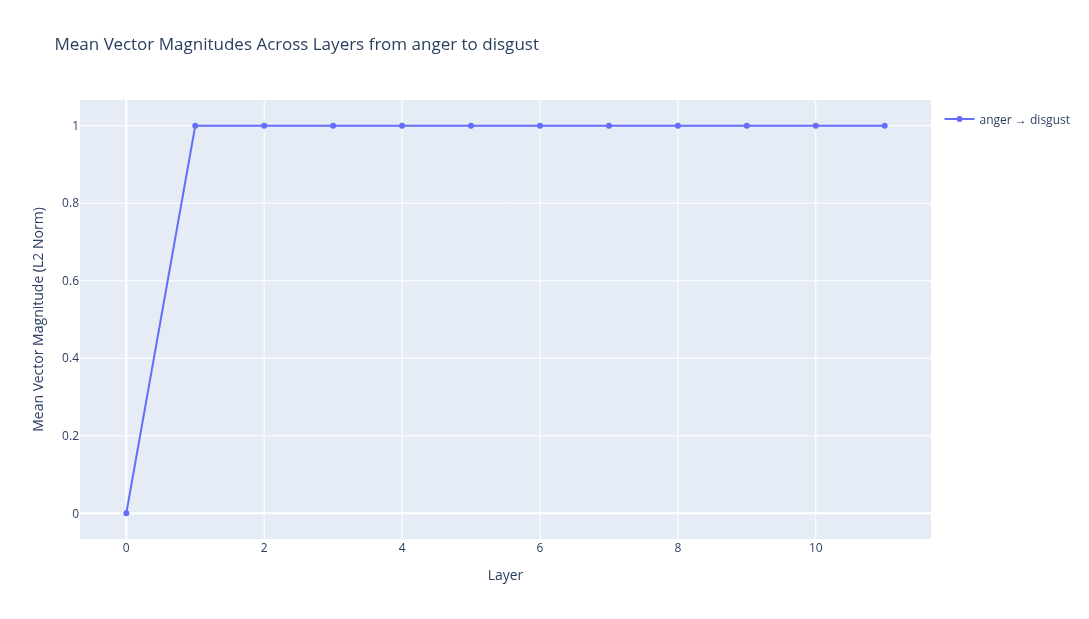

In [20]:
fig = make_subplots(
    rows=1, cols=1,
    specs=[[{"secondary_y": False}]]
)

emotion_pairs = df_plot['emotion_pair'].unique()
colors = px.colors.qualitative.Plotly

for idx, pair in enumerate(sorted(emotion_pairs)):
    pair_data = df_plot[df_plot['emotion_pair'] == pair].sort_values('layer')
    color = colors[idx % len(colors)]
    
    fig.add_trace(
        go.Scatter(
            x=pair_data['layer'],
            y=pair_data['mean_magnitude'],
            mode='lines+markers',
            name=pair,
            line=dict(width=2, color=color),
            marker=dict(size=6),
            hovertemplate=(
                '<b>%{fullData.name}</b><br>'
                'Layer: %{x}<br>'
                'Mean Magnitude: %{y:.4f}<extra></extra>'
            )
        )
    )

title_suffix = ""
if SELECT_EMOTION_FROM:
    title_suffix += f" from {SELECT_EMOTION_FROM}"
if SELECT_EMOTION_TO:
    title_suffix += f" to {SELECT_EMOTION_TO}"

fig.update_layout(
    title=f"Mean Vector Magnitudes Across Layers{title_suffix}",
    xaxis_title="Layer",
    yaxis_title="Mean Vector Magnitude (L2 Norm)",
    hovermode='x unified',
    height=600,
    width=1200,
    showlegend=True,
    legend=dict(
        orientation="v",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.01
    )
)

fig.show()


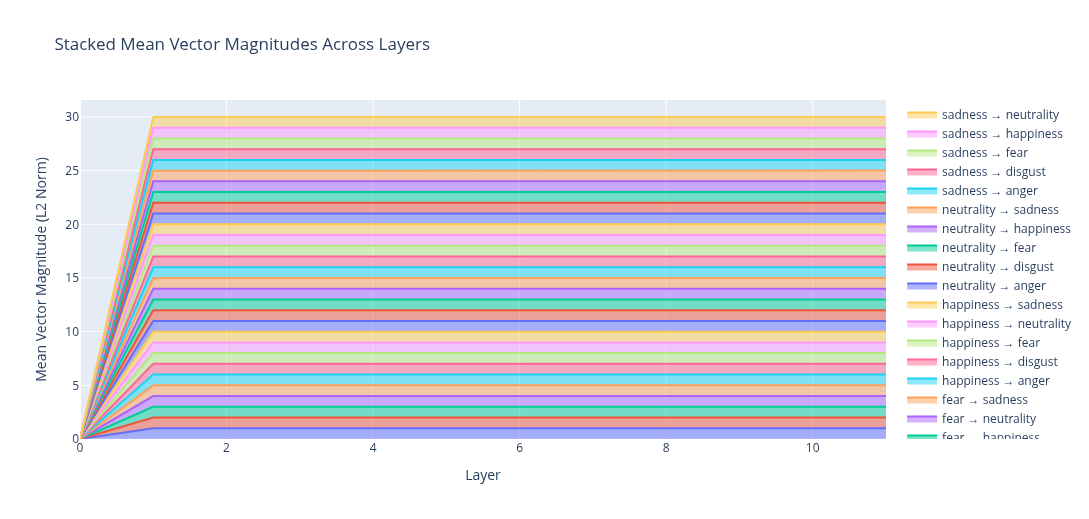

In [21]:
fig = go.Figure()

emotions = sorted(df['emotion_from'].unique())
emotion_pairs_unique = sorted(df['emotion_pair'].unique())

for pair in emotion_pairs_unique:
    pair_data = df[df['emotion_pair'] == pair].sort_values('layer')
    fig.add_trace(
        go.Scatter(
            x=pair_data['layer'],
            y=pair_data['mean_magnitude'],
            mode='lines',
            name=pair,
            stackgroup='one',
            fillcolor=None,
            hovertemplate='<b>%{fullData.name}</b><br>Layer: %{x}<br>Mean Magnitude: %{y:.4f}<extra></extra>'
        )
    )

fig.update_layout(
    title="Stacked Mean Vector Magnitudes Across Layers",
    xaxis_title="Layer",
    yaxis_title="Mean Vector Magnitude (L2 Norm)",
    height=500,
    width=1200,
    hovermode='x unified'
)

fig.show()


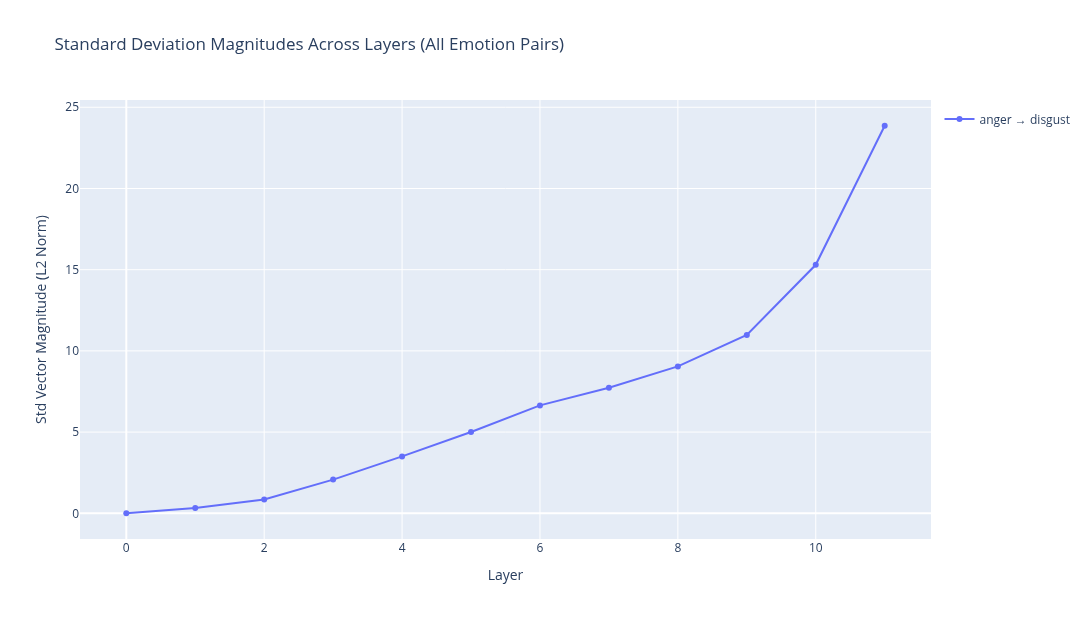

In [22]:
fig = make_subplots(rows=1, cols=1)

for idx, pair in enumerate(sorted(emotion_pairs)):
    pair_data = df[df['emotion_pair'] == pair].sort_values('layer')
    color = colors[idx % len(colors)]
    
    fig.add_trace(
        go.Scatter(
            x=pair_data['layer'],
            y=pair_data['std_magnitude'],
            mode='lines+markers',
            name=pair,
            line=dict(width=2, color=color),
            marker=dict(size=6),
            hovertemplate='<b>%{fullData.name}</b><br>Layer: %{x}<br>Std Magnitude: %{y:.4f}<extra></extra>'
        )
    )

fig.update_layout(
    title="Standard Deviation Magnitudes Across Layers (All Emotion Pairs)",
    xaxis_title="Layer",
    yaxis_title="Std Vector Magnitude (L2 Norm)",
    hovermode='x unified',
    height=600,
    width=1200,
    showlegend=True,
    legend=dict(
        orientation="v",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.01
    )
)

fig.show()


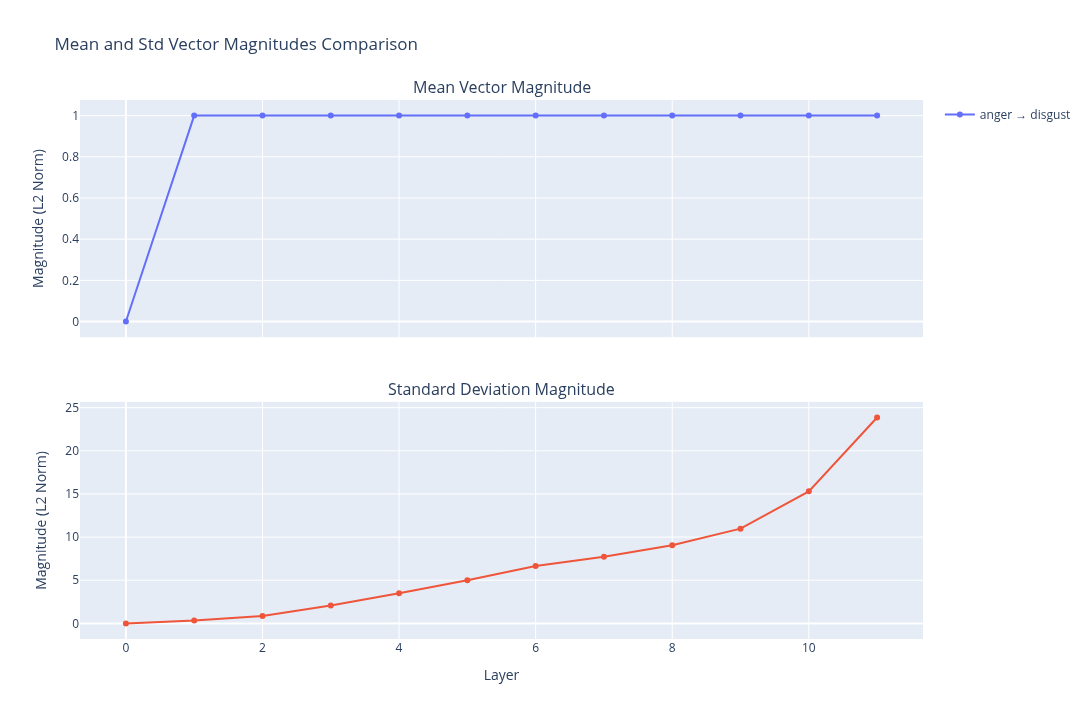

In [23]:
emotion_pairs_list = sorted(emotion_pairs)

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Mean Vector Magnitude", "Standard Deviation Magnitude"),
    shared_xaxes=True,
    vertical_spacing=0.12
)

for pair in emotion_pairs_list:
    pair_data = df[df['emotion_pair'] == pair].sort_values('layer')
    
    fig.add_trace(
        go.Scatter(
            x=pair_data['layer'],
            y=pair_data['mean_magnitude'],
            mode='lines+markers',
            name=pair,
            hovertemplate='<b>%{fullData.name}</b><br>Layer: %{x}<br>Mean: %{y:.4f}<extra></extra>',
            showlegend=True
        ),
        row=1, col=1
    )
    
    fig.add_trace(
        go.Scatter(
            x=pair_data['layer'],
            y=pair_data['std_magnitude'],
            mode='lines+markers',
            name=pair,
            showlegend=False,
            hovertemplate='<b>%{fullData.name}</b><br>Layer: %{x}<br>Std: %{y:.4f}<extra></extra>'
        ),
        row=2, col=1
    )

fig.update_yaxes(title_text="Magnitude (L2 Norm)", row=1, col=1)
fig.update_yaxes(title_text="Magnitude (L2 Norm)", row=2, col=1)
fig.update_xaxes(title_text="Layer", row=2, col=1)

fig.update_layout(
    title="Mean and Std Vector Magnitudes Comparison",
    height=700,
    width=1200,
    hovermode='x unified'
)

fig.show()


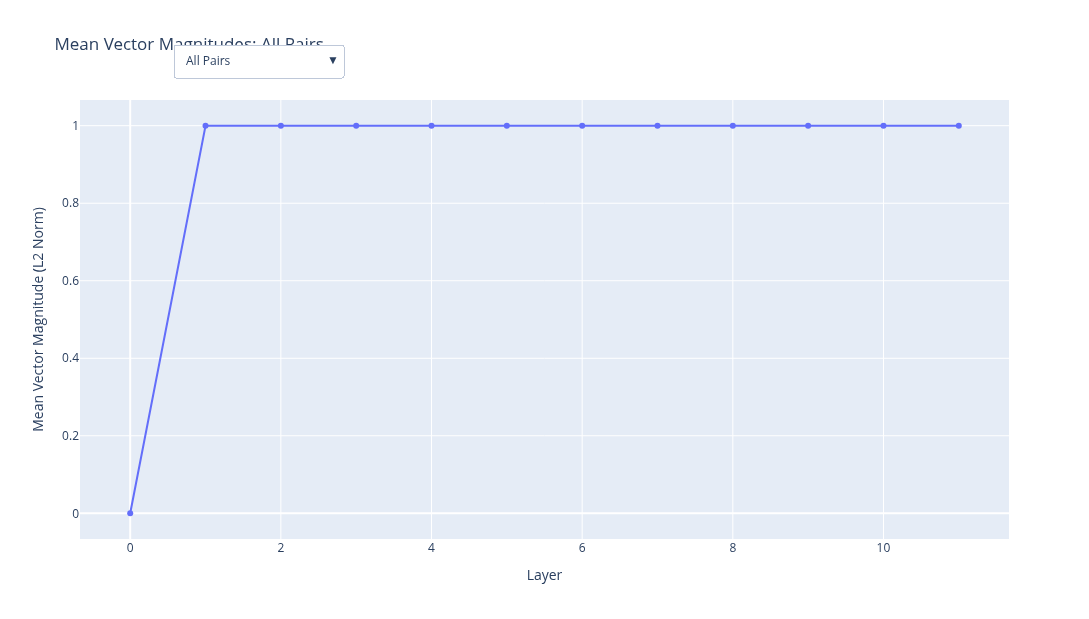

In [24]:
emotion_pairs_sorted = sorted(df['emotion_pair'].unique())

buttons = [
    dict(
        label="All Pairs",
        method="update",
        args=[
            {"visible": [True] * len(emotion_pairs_sorted)},
            {"title": "Mean Vector Magnitudes: All Pairs"}
        ]
    )
]

for i, pair in enumerate(emotion_pairs_sorted):
    visibility = [j == i for j in range(len(emotion_pairs_sorted))]
    buttons.append(
        dict(
            label=pair,
            method="update",
            args=[
                {"visible": visibility},
                {"title": f"Mean Vector Magnitudes: {pair}"}
            ]
        )
    )

fig = go.Figure()

for idx, pair in enumerate(emotion_pairs_sorted):
    pair_data = df[df['emotion_pair'] == pair].sort_values('layer')
    fig.add_trace(
        go.Scatter(
            x=pair_data['layer'],
            y=pair_data['mean_magnitude'],
            mode='lines+markers',
            name=pair,
            visible=(idx == 0),
            hovertemplate='<b>%{fullData.name}</b><br>Layer: %{x}<br>Mean: %{y:.4f}<extra></extra>'
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.15,
            yanchor="top"
        )
    ],
    title="Mean Vector Magnitudes: All Pairs",
    xaxis_title="Layer",
    yaxis_title="Mean Vector Magnitude (L2 Norm)",
    height=600,
    width=1200,
    hovermode='x unified'
)

fig.show()


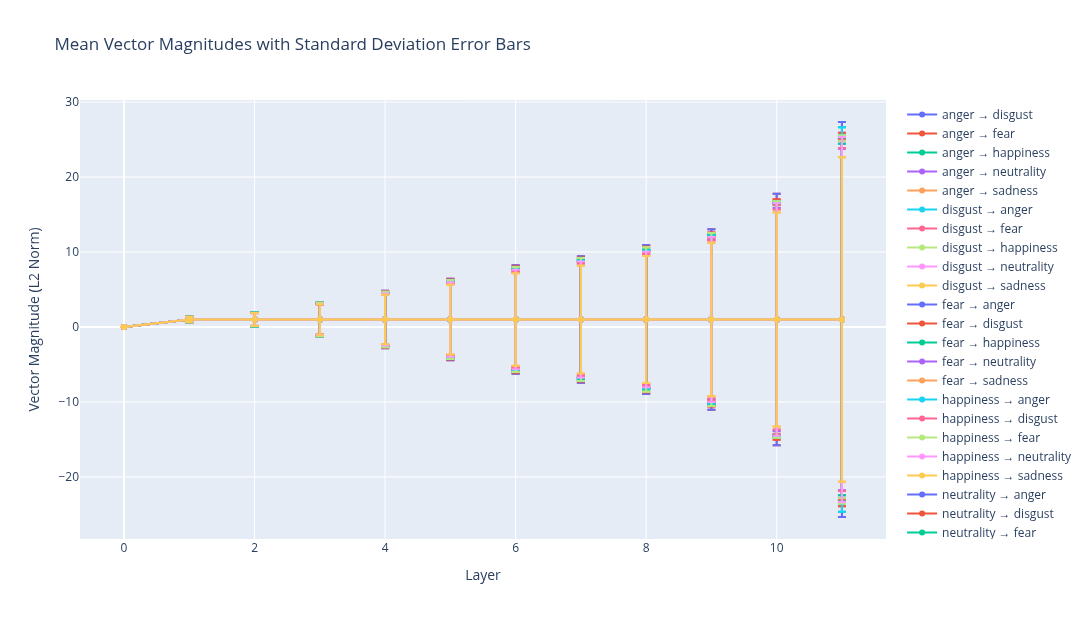

In [25]:
fig = go.Figure()

for pair in emotion_pairs_sorted:
    pair_data = df[df['emotion_pair'] == pair].sort_values('layer')
    
    fig.add_trace(
        go.Scatter(
            x=pair_data['layer'],
            y=pair_data['mean_magnitude'],
            error_y=dict(
                type='data',
                array=pair_data['std_magnitude'],
                visible=True
            ),
            mode='lines+markers',
            name=pair,
            hovertemplate='<b>%{fullData.name}</b><br>Layer: %{x}<br>Mean±Std: %{y:.4f}±%{error_y.array:.4f}<extra></extra>'
        )
    )

fig.update_layout(
    title="Mean Vector Magnitudes with Standard Deviation Error Bars",
    xaxis_title="Layer",
    yaxis_title="Vector Magnitude (L2 Norm)",
    height=600,
    width=1200,
    hovermode='x unified',
    showlegend=True
)

fig.show()


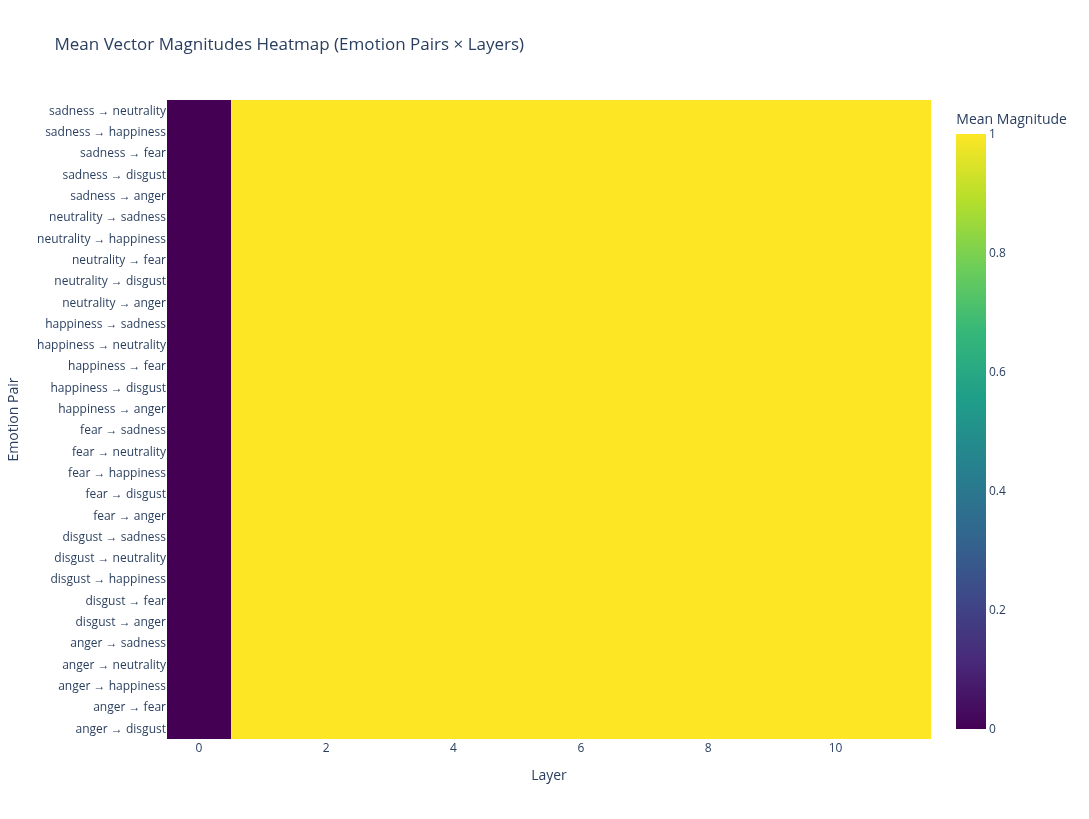

In [26]:
pivot_mean = df.pivot(index='emotion_pair', columns='layer', values='mean_magnitude')

fig = go.Figure(data=go.Heatmap(
    z=pivot_mean.values,
    x=pivot_mean.columns,
    y=pivot_mean.index,
    colorscale='Viridis',
    colorbar=dict(title="Mean Magnitude")
))

fig.update_layout(
    title="Mean Vector Magnitudes Heatmap (Emotion Pairs × Layers)",
    xaxis_title="Layer",
    yaxis_title="Emotion Pair",
    height=800,
    width=1200,
    yaxis=dict(tickangle=0)
)

fig.show()


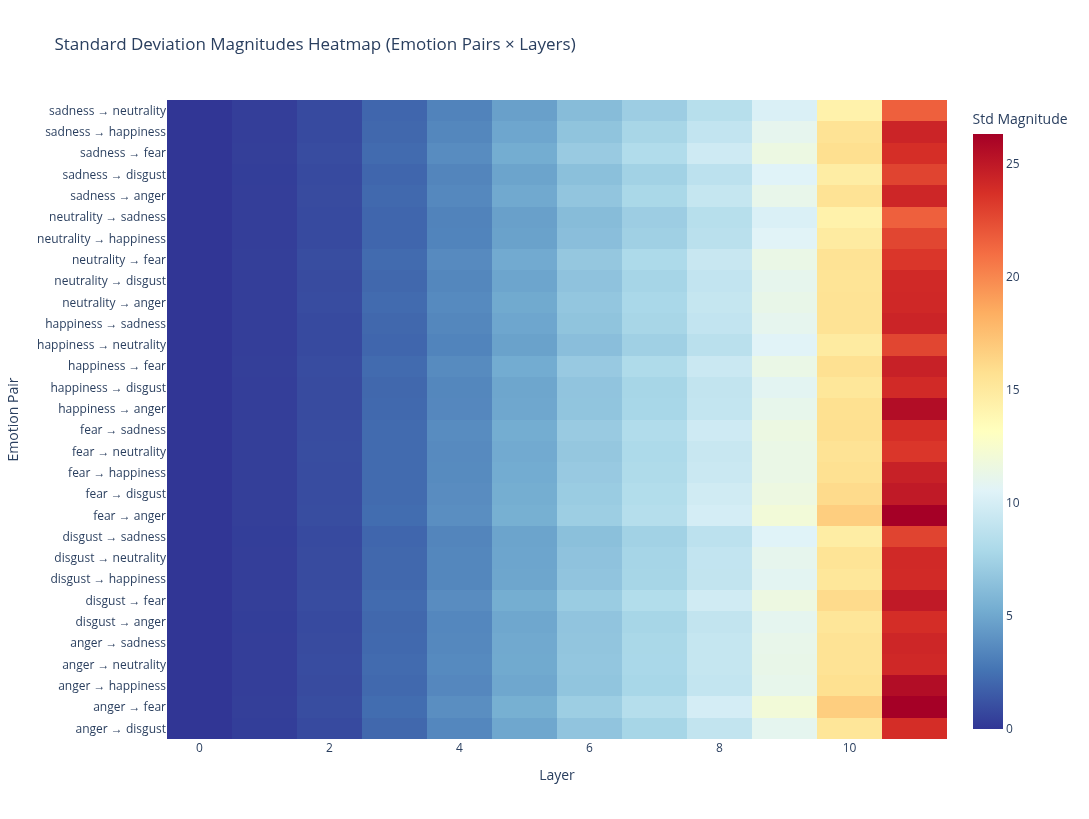

In [27]:
pivot_std = df.pivot(index='emotion_pair', columns='layer', values='std_magnitude')

fig = go.Figure(data=go.Heatmap(
    z=pivot_std.values,
    x=pivot_std.columns,
    y=pivot_std.index,
    colorscale='RdYlBu_r',
    colorbar=dict(title="Std Magnitude")
))

fig.update_layout(
    title="Standard Deviation Magnitudes Heatmap (Emotion Pairs × Layers)",
    xaxis_title="Layer",
    yaxis_title="Emotion Pair",
    height=800,
    width=1200,
    yaxis=dict(tickangle=0)
)

fig.show()


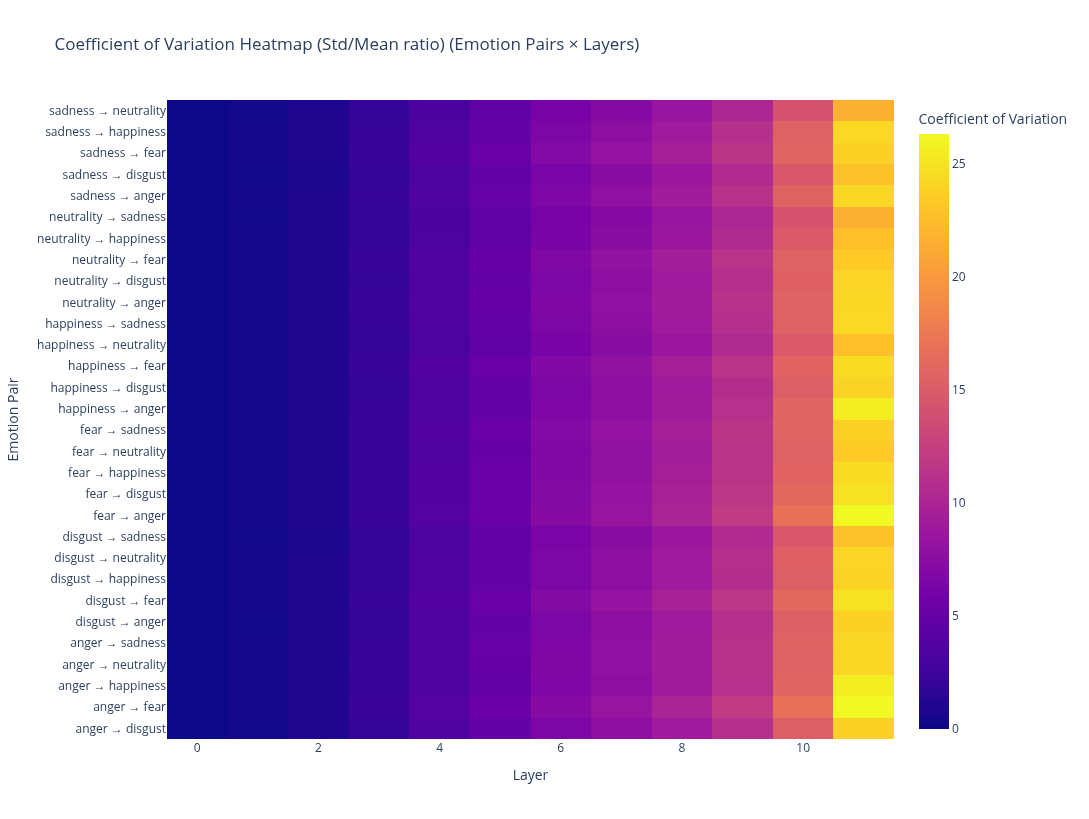

In [28]:
pivot_ratio = df.copy()
pivot_ratio['cv'] = pivot_ratio['std_magnitude'] / (pivot_ratio['mean_magnitude'] + 1e-6)
pivot_ratio = pivot_ratio.pivot(index='emotion_pair', columns='layer', values='cv')

fig = go.Figure(data=go.Heatmap(
    z=pivot_ratio.values,
    x=pivot_ratio.columns,
    y=pivot_ratio.index,
    colorscale='Plasma',
    colorbar=dict(title="Coefficient of Variation")
))

fig.update_layout(
    title="Coefficient of Variation Heatmap (Std/Mean ratio) (Emotion Pairs × Layers)",
    xaxis_title="Layer",
    yaxis_title="Emotion Pair",
    height=800,
    width=1200,
    yaxis=dict(tickangle=0)
)

fig.show()


In [29]:
print("=" * 80)
print("SUMMARY STATISTICS & INSIGHTS")
print("=" * 80)

print("\n1. MEAN MAGNITUDE STATISTICS PER EMOTION PAIR")
print("-" * 80)
pair_stats = df.groupby('emotion_pair').agg({
    'mean_magnitude': ['mean', 'std', 'min', 'max'],
    'std_magnitude': ['mean', 'std']
}).round(4)
pair_stats.columns = ['Mean (avg)', 'Mean (std)', 'Mean (min)', 'Mean (max)', 'Std (avg)', 'Std (std)']
print(pair_stats.sort_values('Mean (avg)', ascending=False))

print("\n2. TOP 10 MOST DISCRIMINATIVE EMOTION PAIRS (by mean magnitude)")
print("-" * 80)
top_pairs = df.groupby('emotion_pair')['mean_magnitude'].mean().sort_values(ascending=False).head(10)
for pair, magnitude in top_pairs.items():
    print(f"  {pair:40s} → {magnitude:.6f}")

print("\n3. TOP 10 LEAST DISCRIMINATIVE EMOTION PAIRS (by mean magnitude)")
print("-" * 80)
bottom_pairs = df.groupby('emotion_pair')['mean_magnitude'].mean().sort_values(ascending=True).head(10)
for pair, magnitude in bottom_pairs.items():
    print(f"  {pair:40s} → {magnitude:.6f}")

print("\n4. LAYER-WISE STATISTICS")
print("-" * 80)
layer_stats = df.groupby('layer').agg({
    'mean_magnitude': ['mean', 'std', 'min', 'max'],
    'std_magnitude': 'mean'
}).round(4)
layer_stats.columns = ['Mean_avg', 'Mean_std', 'Mean_min', 'Mean_max', 'Std_avg']
print(layer_stats)

print("\n5. MOST INFORMATIVE LAYERS (highest mean magnitude)")
print("-" * 80)
layer_means = df.groupby('layer')['mean_magnitude'].mean().sort_values(ascending=False)
for layer, magnitude in layer_means.head(5).items():
    print(f"  Layer {int(layer):2d} → {magnitude:.6f}")

print("\n6. LEAST INFORMATIVE LAYERS (lowest mean magnitude)")
print("-" * 80)
for layer, magnitude in layer_means.tail(5).items():
    print(f"  Layer {int(layer):2d} → {magnitude:.6f}")


SUMMARY STATISTICS & INSIGHTS

1. MEAN MAGNITUDE STATISTICS PER EMOTION PAIR
--------------------------------------------------------------------------------
                        Mean (avg)  Mean (std)  Mean (min)  Mean (max)  \
emotion_pair                                                             
anger → disgust             0.9167      0.2887         0.0         1.0   
anger → fear                0.9167      0.2887         0.0         1.0   
anger → happiness           0.9167      0.2887         0.0         1.0   
anger → neutrality          0.9167      0.2887         0.0         1.0   
anger → sadness             0.9167      0.2887         0.0         1.0   
disgust → anger             0.9167      0.2887         0.0         1.0   
disgust → fear              0.9167      0.2887         0.0         1.0   
disgust → happiness         0.9167      0.2887         0.0         1.0   
disgust → neutrality        0.9167      0.2887         0.0         1.0   
disgust → sadness           

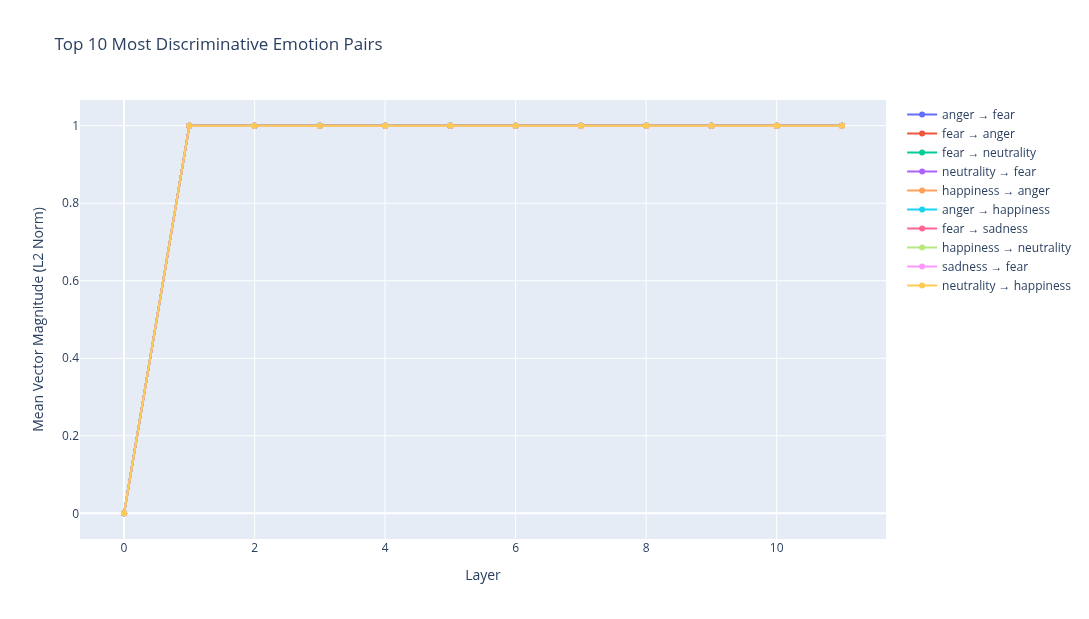

In [30]:
top_n = 10
top_pairs_list = df.groupby('emotion_pair')['mean_magnitude'].mean().sort_values(ascending=False).head(top_n).index.tolist()

fig = go.Figure()

for pair in top_pairs_list:
    pair_data = df[df['emotion_pair'] == pair].sort_values('layer')
    fig.add_trace(
        go.Scatter(
            x=pair_data['layer'],
            y=pair_data['mean_magnitude'],
            mode='lines+markers',
            name=pair,
            hovertemplate='<b>%{fullData.name}</b><br>Layer: %{x}<br>Mean: %{y:.4f}<extra></extra>'
        )
    )

fig.update_layout(
    title=f"Top {top_n} Most Discriminative Emotion Pairs",
    xaxis_title="Layer",
    yaxis_title="Mean Vector Magnitude (L2 Norm)",
    height=600,
    width=1200,
    hovermode='x unified'
)

fig.show()


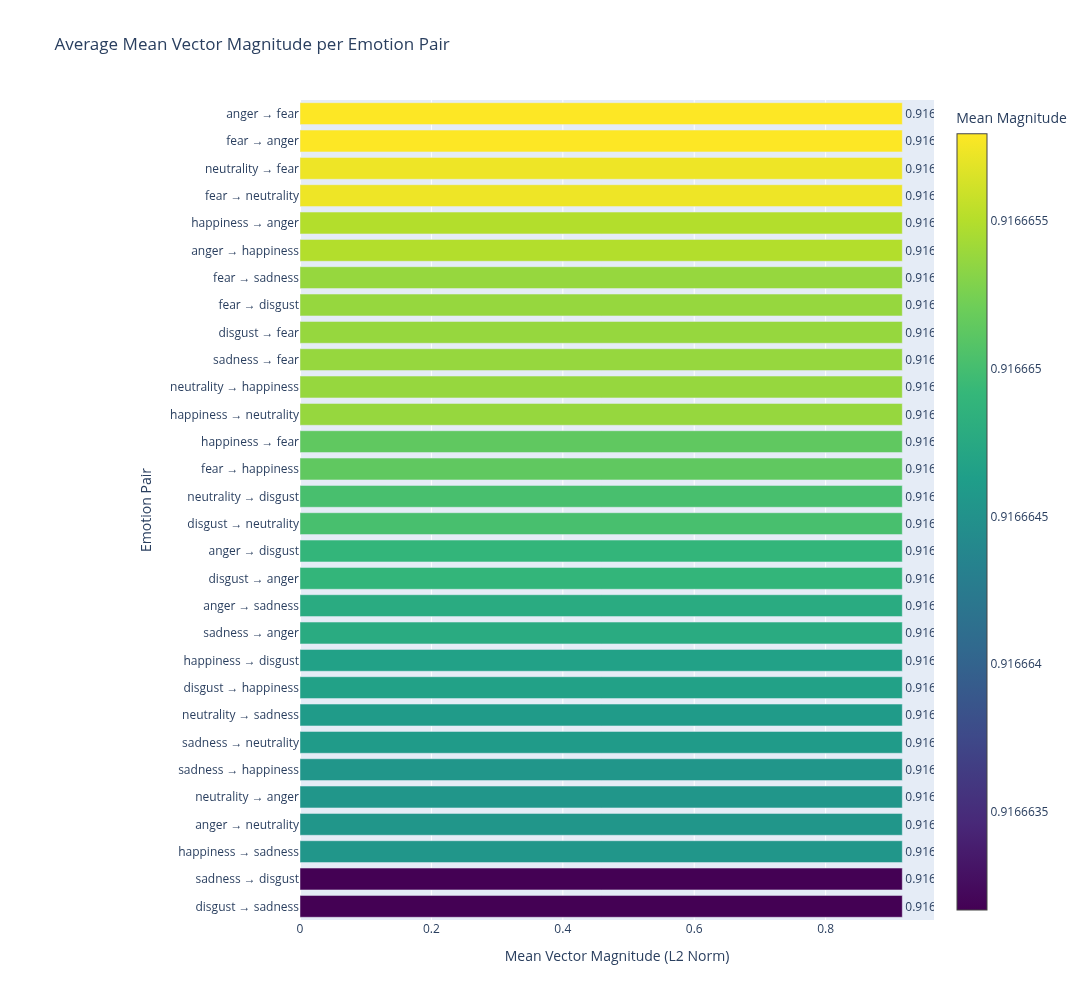

In [31]:
pair_means = df.groupby('emotion_pair')['mean_magnitude'].mean().sort_values(ascending=True)

fig = go.Figure(
    data=[go.Bar(
        y=pair_means.index,
        x=pair_means.values,
        orientation='h',
        marker=dict(
            color=pair_means.values,
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title="Mean Magnitude")
        ),
        text=pair_means.values.round(4),
        textposition='outside',
        hovertemplate='<b>%{y}</b><br>Mean Magnitude: %{x:.4f}<extra></extra>'
    )]
)

fig.update_layout(
    title="Average Mean Vector Magnitude per Emotion Pair",
    xaxis_title="Mean Vector Magnitude (L2 Norm)",
    yaxis_title="Emotion Pair",
    height=1000,
    width=1000,
    margin=dict(l=300)
)

fig.show()


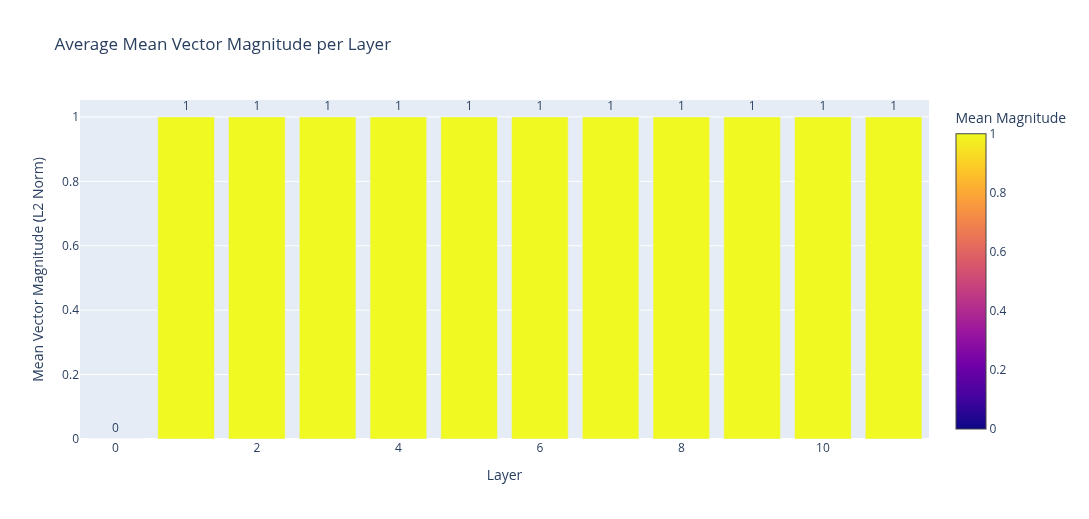

In [32]:
layer_means_sorted = df.groupby('layer')['mean_magnitude'].mean().sort_values()

fig = go.Figure(
    data=[go.Bar(
        x=layer_means_sorted.index,
        y=layer_means_sorted.values,
        marker=dict(
            color=layer_means_sorted.values,
            colorscale='Plasma',
            showscale=True,
            colorbar=dict(title="Mean Magnitude")
        ),
        text=layer_means_sorted.values.round(4),
        textposition='outside',
        hovertemplate='Layer %{x}<br>Mean Magnitude: %{y:.4f}<extra></extra>'
    )]
)

fig.update_layout(
    title="Average Mean Vector Magnitude per Layer",
    xaxis_title="Layer",
    yaxis_title="Mean Vector Magnitude (L2 Norm)",
    height=500,
    width=1200
)

fig.show()


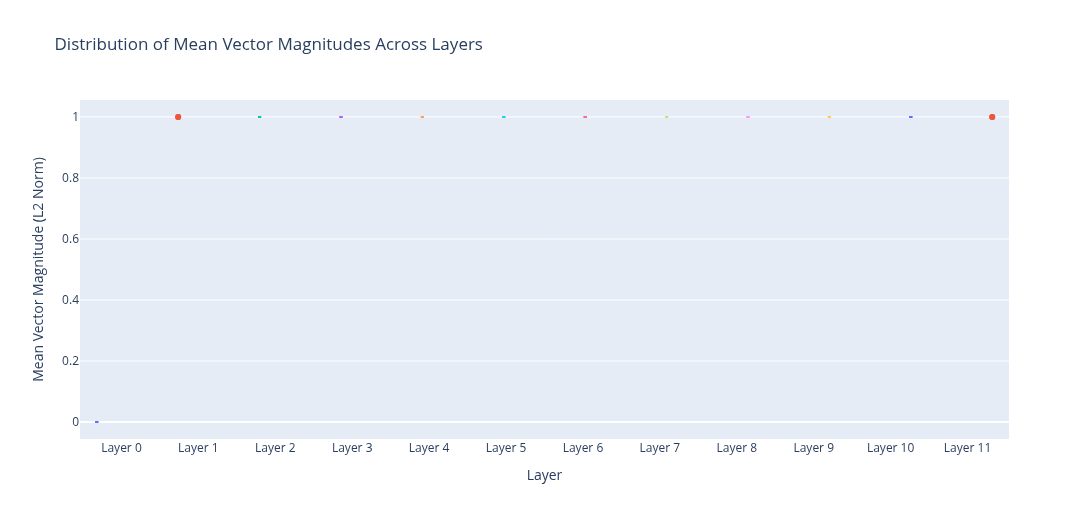

In [33]:
fig = go.Figure()

for layer in sorted(df['layer'].unique()):
    layer_data = df[df['layer'] == layer]
    fig.add_trace(
        go.Box(
            y=layer_data['mean_magnitude'],
            name=f"Layer {int(layer)}",
            boxmean='sd',
            hovertemplate='Layer %{fullData.name}<br>Mean Magnitude: %{y:.4f}<extra></extra>'
        )
    )

fig.update_layout(
    title="Distribution of Mean Vector Magnitudes Across Layers",
    yaxis_title="Mean Vector Magnitude (L2 Norm)",
    xaxis_title="Layer",
    height=500,
    width=1400,
    boxmode='group',
    showlegend=False
)

fig.show()


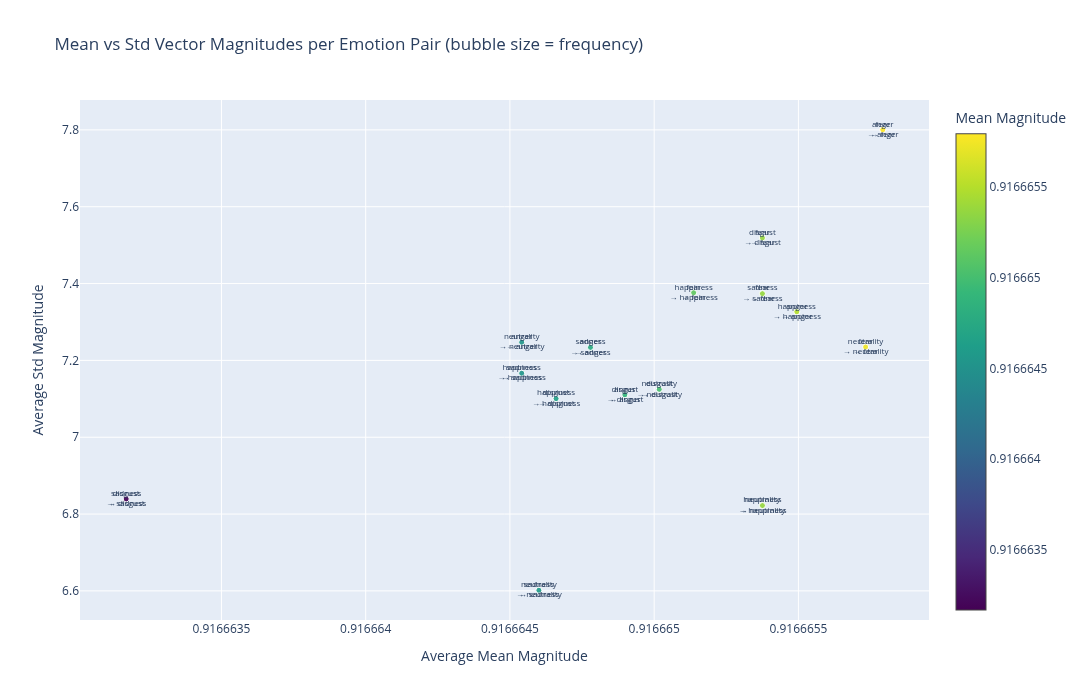

In [34]:
fig = go.Figure()

pair_summary = df.groupby('emotion_pair').agg({
    'mean_magnitude': 'mean',
    'std_magnitude': 'mean',
    'emotion_pair': 'count'
}).rename(columns={'emotion_pair': 'count'})

fig = go.Figure(
    data=[go.Scatter(
        x=pair_summary['mean_magnitude'],
        y=pair_summary['std_magnitude'],
        mode='markers+text',
        marker=dict(
            size=pair_summary['count'] / 2,
            color=pair_summary['mean_magnitude'],
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title="Mean Magnitude"),
            line=dict(width=1, color='white')
        ),
        text=[pair.replace(' → ', '<br>→ ') for pair in pair_summary.index],
        textposition='middle center',
        textfont=dict(size=8),
        hovertemplate='<b>%{text}</b><br>Mean: %{x:.4f}<br>Std: %{y:.4f}<extra></extra>',
        showlegend=False
    )]
)

fig.update_layout(
    title="Mean vs Std Vector Magnitudes per Emotion Pair (bubble size = frequency)",
    xaxis_title="Average Mean Magnitude",
    yaxis_title="Average Std Magnitude",
    height=700,
    width=900
)

fig.show()


In [35]:
print("\n" + "=" * 80)
print("EMOTION PAIR CONSISTENCY ANALYSIS")
print("=" * 80)

consistency_data = []
for layer in df['layer'].unique():
    for pair in df[df['layer'] == layer]['emotion_pair'].unique():
        pair_data = df[(df['layer'] == layer) & (df['emotion_pair'] == pair)]
        if len(pair_data) > 0:
            row = pair_data.iloc[0]
            num_identities = int(row['num_identities'])
            consistency_data.append({
                'layer': int(layer),
                'emotion_pair': pair,
                'num_identities': num_identities,
                'mean_magnitude': row['mean_magnitude'],
                'std_magnitude': row['std_magnitude'],
                'cv': row['std_magnitude'] / (row['mean_magnitude'] + 1e-6)
            })

consistency_df = pd.DataFrame(consistency_data)

print("\nMost consistent emotion pairs (lowest Coefficient of Variation):")
print("-" * 80)
most_consistent = consistency_df.groupby('emotion_pair')['cv'].mean().sort_values().head(10)
for pair, cv in most_consistent.items():
    print(f"  {pair:40s} → CV: {cv:.4f}")

print("\nLeast consistent emotion pairs (highest Coefficient of Variation):")
print("-" * 80)
least_consistent = consistency_df.groupby('emotion_pair')['cv'].mean().sort_values(ascending=False).head(10)
for pair, cv in least_consistent.items():
    print(f"  {pair:40s} → CV: {cv:.4f}")

print("\nIdentity counts per emotion pair:")
print("-" * 80)
identity_counts = consistency_df.groupby('emotion_pair')['num_identities'].mean().sort_values(ascending=False)
for pair, count in identity_counts.items():
    print(f"  {pair:40s} → {count:.0f} identities")



EMOTION PAIR CONSISTENCY ANALYSIS

Most consistent emotion pairs (lowest Coefficient of Variation):
--------------------------------------------------------------------------------
  neutrality → sadness                     → CV: 6.6016
  sadness → neutrality                     → CV: 6.6016
  neutrality → happiness                   → CV: 6.8221
  happiness → neutrality                   → CV: 6.8221
  disgust → sadness                        → CV: 6.8393
  sadness → disgust                        → CV: 6.8393
  happiness → disgust                      → CV: 7.1004
  disgust → happiness                      → CV: 7.1004
  disgust → anger                          → CV: 7.1104
  anger → disgust                          → CV: 7.1104

Least consistent emotion pairs (highest Coefficient of Variation):
--------------------------------------------------------------------------------
  anger → fear                             → CV: 7.8003
  fear → anger                             → CV: 7.80

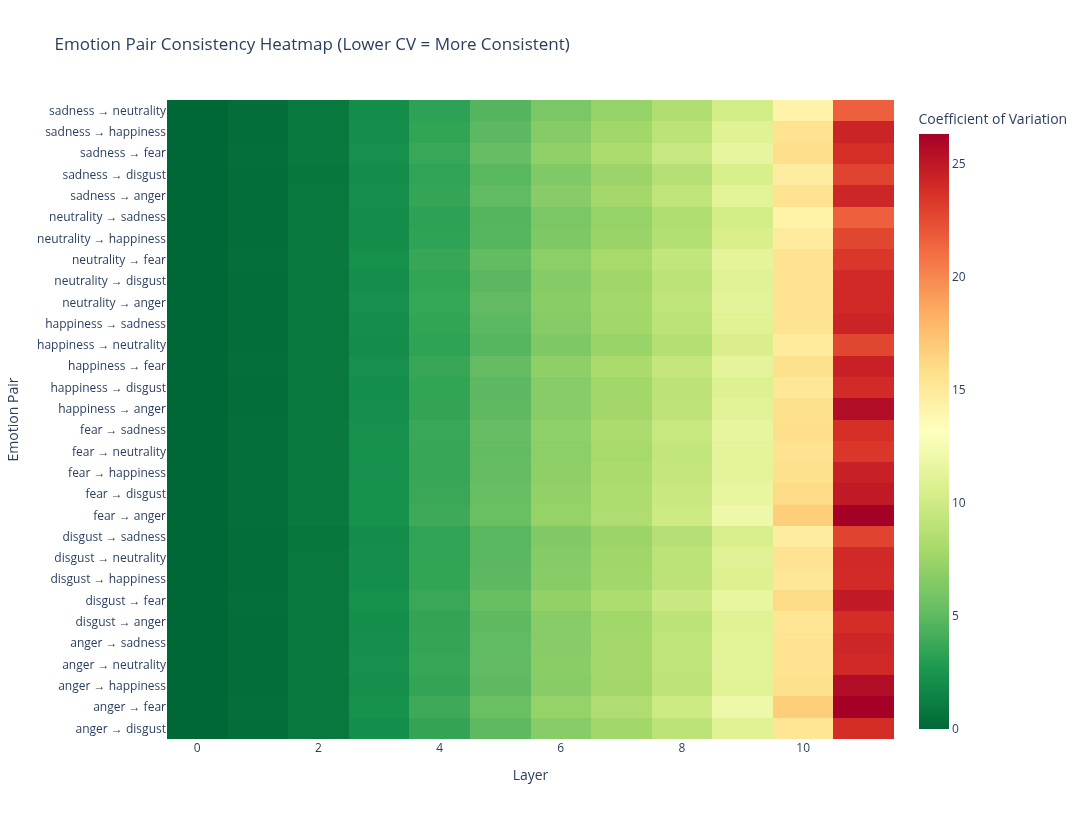

In [36]:
pivot_cv = consistency_df.pivot(index='emotion_pair', columns='layer', values='cv')

fig = go.Figure(data=go.Heatmap(
    z=pivot_cv.values,
    x=pivot_cv.columns,
    y=pivot_cv.index,
    colorscale='RdYlGn_r',
    colorbar=dict(title="Coefficient of Variation")
))

fig.update_layout(
    title="Emotion Pair Consistency Heatmap (Lower CV = More Consistent)",
    xaxis_title="Layer",
    yaxis_title="Emotion Pair",
    height=800,
    width=1200,
    yaxis=dict(tickangle=0)
)

fig.show()


In [37]:
print("\n" + "=" * 80)
print("FINAL SUMMARY TABLE: KEY METRICS PER EMOTION PAIR")
print("=" * 80)

summary_table = df.groupby('emotion_pair').agg({
    'mean_magnitude': ['mean', 'std', 'max'],
    'std_magnitude': 'mean',
    'num_identities': 'first'
}).round(4)

summary_table.columns = ['Mean (avg)', 'Mean (std)', 'Mean (max)', 'Std (avg)', 'Num Identities']
summary_table['CV (avg)'] = (summary_table['Std (avg)'] / (summary_table['Mean (avg)'] + 1e-6)).round(4)
summary_table = summary_table.sort_values('Mean (avg)', ascending=False)

print("\n")
print(summary_table.to_string())

print("\n" + "=" * 80)
print("Key Findings:")
print("=" * 80)
print(f"✓ Total emotion pairs analyzed: {df['emotion_pair'].nunique()}")
print(f"✓ Total layers analyzed: {df['layer'].nunique()}")
print(f"✓ Most discriminative pair: {summary_table.index[0]}")
print(f"  └─ Mean magnitude: {summary_table['Mean (avg)'].iloc[0]:.6f}")
print(f"✓ Least discriminative pair: {summary_table.index[-1]}")
print(f"  └─ Mean magnitude: {summary_table['Mean (avg)'].iloc[-1]:.6f}")
print(f"✓ Most consistent pair (lowest CV): {df.groupby('emotion_pair').apply(lambda x: (x['std_magnitude'] / (x['mean_magnitude'] + 1e-6)).mean()).idxmin()}")
print(f"✓ Peak discriminability at layer: {df.groupby('layer')['mean_magnitude'].mean().idxmax()}")
print("=" * 80)



FINAL SUMMARY TABLE: KEY METRICS PER EMOTION PAIR


                        Mean (avg)  Mean (std)  Mean (max)  Std (avg)  Num Identities  CV (avg)
emotion_pair                                                                                   
anger → disgust             0.9167      0.2887         1.0     7.1104             119    7.7565
anger → fear                0.9167      0.2887         1.0     7.8004             119    8.5092
anger → happiness           0.9167      0.2887         1.0     7.3264             119    7.9921
anger → neutrality          0.9167      0.2887         1.0     7.2472             119    7.9057
anger → sadness             0.9167      0.2887         1.0     7.2338             119    7.8911
disgust → anger             0.9167      0.2887         1.0     7.1104             119    7.7565
disgust → fear              0.9167      0.2887         1.0     7.5187             119    8.2019
disgust → happiness         0.9167      0.2887         1.0     7.1004             1

## Additional Analysis: Emotion Representation Space

Detailed analysis of individual emotion pair dynamics.


## Section 7: Summary Statistics and Insights

Compute and display aggregate statistics about emotion separability and discriminative layers.


## Section 6: Generate Heatmaps for Pairwise Differences

Create heatmaps showing the magnitude of differences between emotion pairs across all layers.


## Section 5: Create Interactive Emotion Pair Comparison

Build interactive plots allowing dynamic selection of emotion pairs and layers.


## Section 4: Visualize Standard Deviation Across Layers

Generate plots showing the variance of emotion vectors across different layers.


## Section 3: Visualize Mean Vectors Across Layers

Create line plots showing how mean vector magnitudes change across layers for different emotion pairs.


## Section 2: Organize and Prepare Data for Visualization

Transform the nested dictionary structure into DataFrames for easier manipulation.


## Section 1: Load and Inspect Results Data

Load the saved results from the CLSEmotionMeanVector analysis and inspect the structure.


# Emotion CLS Vector Analysis - Results Visualization

This notebook presents comprehensive analysis of the emotion representation vectors extracted from ViT CLS tokens. We visualize means, standard deviations, and pairwise emotion differences through interactive diagrams.
